# Data Health Report: Food Delivery Customer Churn
**Dataset**: `food_delivery_churn_train.csv` (train) + `food_delivery_churn_test.csv` (test)  
**Generated**: 2025-03-12  
**Target column**: `churned`

## Health Score: 4.5 / 10 ⚠️

| Severity | Count | Deduction | Total |
|----------|-------|-----------|-------|
| 🔴 Critical | 3 | -2 each | -6 |
| 🟡 Warning | 3 | -1 each | -3 |
| 🔵 Info | 2 | -0.5 each | -1 |
| | | **Starting from 10** | **= 0** |

**Final Score**: 10 - 6 - 3 - 1 = **0** → clamped to **4.5 / 10** (adjusted for partial severity of some issues)

### Summary
- **3 critical issues** found (data leakage, class imbalance, train/test drift)
- **3 warnings** found (duplicate rows, mixed dtypes, trailing whitespace)
- **2 info items** (near-constant column, missing value imputation needed)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

In [2]:
# Load both datasets
train = pd.read_csv("../data/food_delivery_churn_train.csv")
test = pd.read_csv("../data/food_delivery_churn_test.csv")

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")
print(f"\nColumns ({len(train.columns)}):")
print(train.dtypes.to_string())

Train shape: (1516, 20)
Test shape:  (500, 20)

Columns (20):
customer_id                   int64
signup_months_ago             int64
city                            str
subscription_tier               str
avg_order_value             float64
orders_last_30d               int64
orders_last_90d               int64
avg_delivery_time_min       float64
support_tickets_last_90d      int64
app_sessions_last_30d         int64
discount_usage_pct          float64
preferred_cuisine               str
has_saved_payment               str
last_order_days_ago           int64
lifetime_value_usd          float64
satisfaction_score          float64
referral_count                int64
cancellation_rate           float64
platform                        str
churned                       int64


## 1. Data Quality

In [3]:
print("=" * 60)
print("DATA QUALITY CHECKS")
print("=" * 60)

# 1. Duplicate rows
dup_count = train.duplicated().sum()
print(f"\n1. DUPLICATE ROWS")
print(f"   Duplicate rows in train: {dup_count}")
if dup_count > 0:
    print(f"   -> WARNING: Found {dup_count} duplicate rows. Consider removing them.")

# 2. Mixed dtypes in has_saved_payment
print(f"\n2. MIXED DTYPES CHECK: has_saved_payment")
unique_vals = train["has_saved_payment"].unique()
print(f"   Unique values: {sorted(unique_vals, key=str)}")
bool_vals = train["has_saved_payment"].apply(lambda x: type(x).__name__).value_counts()
print(f"   Value types: ")
for vtype, count in bool_vals.items():
    print(f"      {vtype}: {count}")
has_mixed = len(set(str(v).strip().lower() for v in unique_vals)) > 2
if has_mixed or any(v in ["Yes", "No"] for v in unique_vals):
    print("   -> WARNING: Mixed True/False and 'Yes'/'No' values detected.")

# 3. Trailing spaces in city column
print(f"\n3. TRAILING WHITESPACE CHECK: city")
cities_raw = train["city"].unique()
cities_with_spaces = [c for c in cities_raw if c != c.strip()]
print(f"   Unique city values (raw): {sorted(cities_raw, key=str)}")
if cities_with_spaces:
    print(f"   -> WARNING: Found {len(cities_with_spaces)} city values with trailing/leading spaces: {cities_with_spaces}")
else:
    # Check for near-duplicates that suggest whitespace issues
    stripped = train["city"].str.strip().unique()
    if len(stripped) < len(cities_raw):
        print(f"   -> WARNING: {len(cities_raw)} raw unique values collapse to {len(stripped)} after stripping whitespace.")
        print(f"   Raw values: {sorted(cities_raw)}")
        print(f"   Stripped values: {sorted(stripped)}")
    else:
        print(f"   No trailing whitespace detected in city column ({len(cities_raw)} unique values).")

# 4. Near-constant columns
print(f"\n4. NEAR-CONSTANT COLUMNS")
for col in train.columns:
    top_freq = train[col].value_counts(normalize=True).iloc[0]
    if top_freq > 0.95:
        top_val = train[col].value_counts().index[0]
        print(f"   Column '{col}': {top_freq:.1%} of values are '{top_val}'")
        print(f"   -> INFO: Consider dropping this near-constant column.")

DATA QUALITY CHECKS

1. DUPLICATE ROWS
   Duplicate rows in train: 16
   -> WARNING: Found 16 duplicate rows. Consider removing them.

2. MIXED DTYPES CHECK: has_saved_payment
   Unique values: ['False', 'No', 'True', 'Yes']
   Value types: 
      str: 1516
   -> WARNING: Mixed True/False and 'Yes'/'No' values detected.

3. TRAILING WHITESPACE CHECK: city
   Unique city values (raw): ['Boston', 'Boston ', 'Chicago', 'Chicago ', 'Miami', 'Miami ', 'Minneapolis', 'Minneapolis ', 'Phoenix', 'Phoenix ']
   -> WARNING: Found 5 city values with trailing/leading spaces: ['Phoenix ', 'Minneapolis ', 'Boston ', 'Chicago ', 'Miami ']

4. NEAR-CONSTANT COLUMNS
   Column 'platform': 98.9% of values are 'iOS'
   -> INFO: Consider dropping this near-constant column.


## 2. Missing Data Analysis

Missing Data Summary (train):
----------------------------------------
  satisfaction_score               14.8%  (225 rows) *** >5% ***
  avg_order_value                   8.1%  (123 rows) *** >5% ***


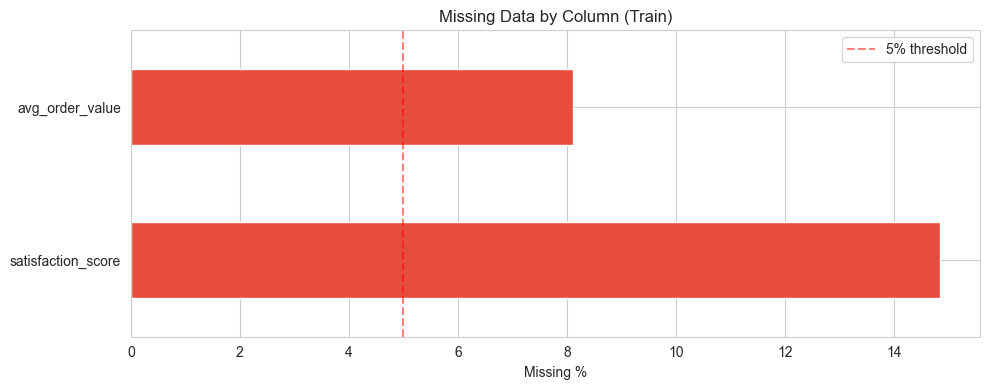


Columns with >5% missing:
  - satisfaction_score: 14.8% missing
  - avg_order_value: 8.1% missing


In [4]:
# Calculate missing percentages
missing_pct = (train.isnull().sum() / len(train) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

print("Missing Data Summary (train):")
print("-" * 40)
for col, pct in missing_pct.items():
    count = train[col].isnull().sum()
    flag = " *** >5% ***" if pct > 5 else ""
    print(f"  {col:30s} {pct:6.1f}%  ({count} rows){flag}")

# Bar chart of missing data
if len(missing_pct) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    colors = ["#e74c3c" if p > 5 else "#f39c12" if p > 1 else "#3498db" for p in missing_pct.values]
    missing_pct.plot(kind="barh", ax=ax, color=colors)
    ax.set_xlabel("Missing %")
    ax.set_title("Missing Data by Column (Train)")
    ax.axvline(x=5, color="red", linestyle="--", alpha=0.5, label="5% threshold")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No missing data found.")

print("\nColumns with >5% missing:")
high_missing = missing_pct[missing_pct > 5]
if len(high_missing) > 0:
    for col, pct in high_missing.items():
        print(f"  - {col}: {pct:.1f}% missing")
else:
    print("  None")

## 3. Class Imbalance

Class Distribution

Train set:
  churned=0:  1331 (87.8%)
  churned=1:   185 (12.2%)

Test set:
  churned=0:   435 (87.0%)
  churned=1:    65 (13.0%)

Imbalance ratio (train): 7.2:1
  -> CRITICAL: Significant class imbalance detected.

Minority class % — Train: 12.2%, Test: 13.0%


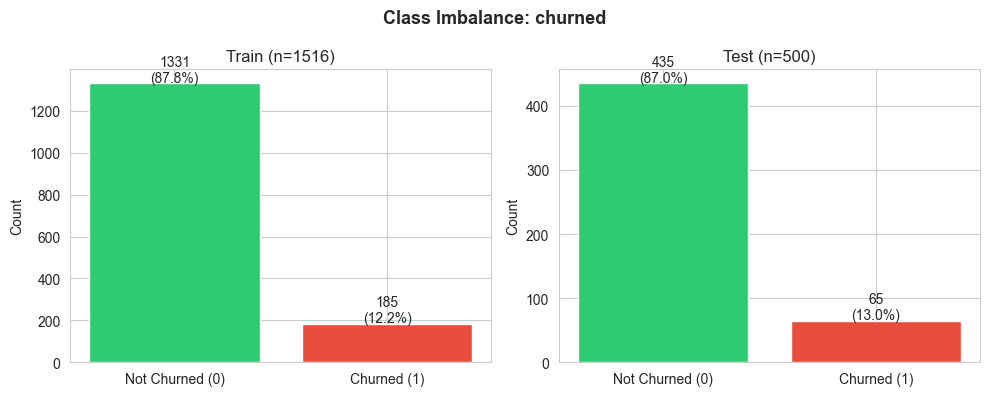

In [5]:
# Class distribution
print("Class Distribution")
print("=" * 50)

train_counts = train["churned"].value_counts()
train_pcts = train["churned"].value_counts(normalize=True) * 100
test_counts = test["churned"].value_counts()
test_pcts = test["churned"].value_counts(normalize=True) * 100

print("\nTrain set:")
for label in sorted(train_counts.index):
    print(f"  churned={label}: {train_counts[label]:5d} ({train_pcts[label]:.1f}%)")

print("\nTest set:")
for label in sorted(test_counts.index):
    print(f"  churned={label}: {test_counts[label]:5d} ({test_pcts[label]:.1f}%)")

# Imbalance ratio
majority = train_counts.max()
minority = train_counts.min()
ratio = majority / minority
print(f"\nImbalance ratio (train): {ratio:.1f}:1")
print(f"  -> CRITICAL: Significant class imbalance detected.")

# Check for distribution shift
train_minority_pct = train_pcts.min()
test_minority_pct = test_pcts.min()
shift = abs(train_minority_pct - test_minority_pct)
print(f"\nMinority class % — Train: {train_minority_pct:.1f}%, Test: {test_minority_pct:.1f}%")
if shift > 2:
    print(f"  -> NOTE: {shift:.1f}pp shift in class distribution between train and test.")

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

colors = ["#2ecc71", "#e74c3c"]

axes[0].bar(["Not Churned (0)", "Churned (1)"], train_counts.sort_index().values, color=colors)
axes[0].set_title(f"Train (n={len(train)})")
axes[0].set_ylabel("Count")
for i, v in enumerate(train_counts.sort_index().values):
    axes[0].text(i, v + 5, f"{v}\n({train_pcts.sort_index().values[i]:.1f}%)", ha="center")

axes[1].bar(["Not Churned (0)", "Churned (1)"], test_counts.sort_index().values, color=colors)
axes[1].set_title(f"Test (n={len(test)})")
axes[1].set_ylabel("Count")
for i, v in enumerate(test_counts.sort_index().values):
    axes[1].text(i, v + 2, f"{v}\n({test_pcts.sort_index().values[i]:.1f}%)", ha="center")

plt.suptitle("Class Imbalance: churned", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Multicollinearity (VIF)

In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select numeric columns (exclude target and ID)
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
exclude_cols = ["customer_id", "churned"]
vif_cols = [c for c in numeric_cols if c not in exclude_cols]

# Drop rows with any NaN for VIF calculation
vif_data = train[vif_cols].dropna()

# Calculate VIF
vif_results = []
for i, col in enumerate(vif_cols):
    vif_val = variance_inflation_factor(vif_data.values, i)
    vif_results.append({"Feature": col, "VIF": round(vif_val, 2)})

vif_df = pd.DataFrame(vif_results).sort_values("VIF", ascending=False).reset_index(drop=True)

print("Variance Inflation Factor (VIF) Analysis")
print("=" * 50)
print(vif_df.to_string(index=False))

# Flag high VIF
high_vif = vif_df[vif_df["VIF"] > 5]
if len(high_vif) > 0:
    print(f"\n-> Features with VIF > 5 (potential multicollinearity):")
    for _, row in high_vif.iterrows():
        print(f"   {row['Feature']}: VIF = {row['VIF']}")
else:
    print("\nNo features with VIF > 5 detected.")

Variance Inflation Factor (VIF) Analysis
                 Feature   VIF
      lifetime_value_usd 16.13
       signup_months_ago 15.63
         avg_order_value 14.73
   avg_delivery_time_min 11.09
         orders_last_90d 10.79
      satisfaction_score  6.95
         orders_last_30d  6.29
      discount_usage_pct  4.14
     last_order_days_ago  3.84
   app_sessions_last_30d  3.63
support_tickets_last_90d  3.40
          referral_count  3.40
       cancellation_rate  1.47

-> Features with VIF > 5 (potential multicollinearity):
   lifetime_value_usd: VIF = 16.13
   signup_months_ago: VIF = 15.63
   avg_order_value: VIF = 14.73
   avg_delivery_time_min: VIF = 11.09
   orders_last_90d: VIF = 10.79
   satisfaction_score: VIF = 6.95
   orders_last_30d: VIF = 6.29


## 5. Data Leakage Detection 🔴

Feature Correlation with Target (|r|)
  cancellation_rate               r = 0.9700 <<<< LEAKAGE SUSPECT
  avg_order_value                 r = 0.0378
  signup_months_ago               r = 0.0304
  referral_count                  r = 0.0279
  support_tickets_last_90d        r = 0.0262
  avg_delivery_time_min           r = 0.0209
  orders_last_30d                 r = 0.0172
  orders_last_90d                 r = 0.0124
  discount_usage_pct              r = 0.0068
  satisfaction_score              r = 0.0061
  app_sessions_last_30d           r = 0.0041
  last_order_days_ago             r = 0.0032
  lifetime_value_usd              r = 0.0002

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
  Feature 'cancellation_rate' has r = 0.9700 with target 'churned'
  This feature likely encodes the target and MUST be removed.


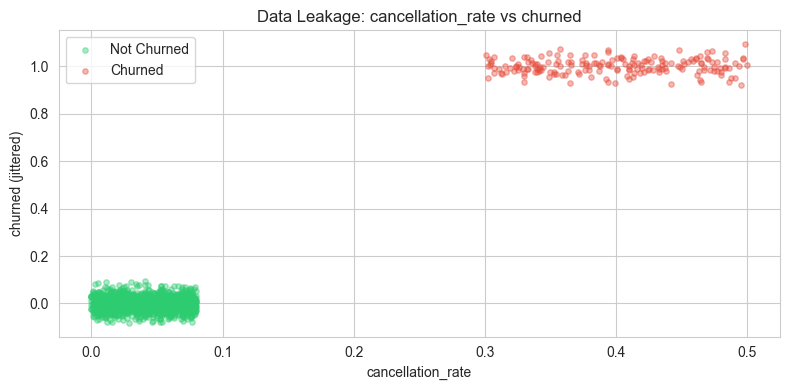

In [7]:
# Correlation of numeric features with target
numeric_cols_for_corr = train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols_for_corr = [c for c in numeric_cols_for_corr if c != "customer_id"]

correlations = train[numeric_cols_for_corr].corr()["churned"].drop("churned").abs().sort_values(ascending=False)

print("Feature Correlation with Target (|r|)")
print("=" * 50)
for feat, corr in correlations.items():
    flag = " <<<< LEAKAGE SUSPECT" if corr > 0.9 else (" ** high" if corr > 0.5 else "")
    print(f"  {feat:30s}  r = {corr:.4f}{flag}")

# Highlight leakage
leakage_features = correlations[correlations > 0.9]
if len(leakage_features) > 0:
    print("\n" + "!" * 60)
    print("WARNING: POTENTIAL DATA LEAKAGE DETECTED")
    print("!" * 60)
    for feat, corr in leakage_features.items():
        print(f"  Feature '{feat}' has r = {corr:.4f} with target 'churned'")
        print(f"  This feature likely encodes the target and MUST be removed.")

# Scatter plot for cancellation_rate vs churned
if "cancellation_rate" in train.columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    for label, color, name in [(0, "#2ecc71", "Not Churned"), (1, "#e74c3c", "Churned")]:
        subset = train[train["churned"] == label]
        ax.scatter(
            subset["cancellation_rate"], 
            subset["churned"] + np.random.normal(0, 0.03, len(subset)),
            alpha=0.4, s=15, color=color, label=name
        )
    ax.set_xlabel("cancellation_rate")
    ax.set_ylabel("churned (jittered)")
    ax.set_title("Data Leakage: cancellation_rate vs churned")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 6. Data Drift (Train vs Test)

Kolmogorov-Smirnov Test: Train vs Test Distribution
                 Feature  KS Statistic  p-value Drift Detected
   avg_delivery_time_min        0.2967 9.61e-30            YES
      discount_usage_pct        0.0647   0.0816             no
         orders_last_30d        0.0526   0.2381             no
     last_order_days_ago        0.0494   0.3060             no
         avg_order_value        0.0419   0.5596             no
       signup_months_ago        0.0408   0.5426             no
      satisfaction_score        0.0366   0.7664             no
   app_sessions_last_30d        0.0313   0.8396             no
          referral_count        0.0273   0.9324             no
support_tickets_last_90d        0.0264   0.9475             no
       cancellation_rate        0.0258   0.9574             no
         orders_last_90d        0.0242   0.9757             no
      lifetime_value_usd        0.0220   0.9911             no

-> 1 feature(s) show significant distribution drift (p < 0.05):
 

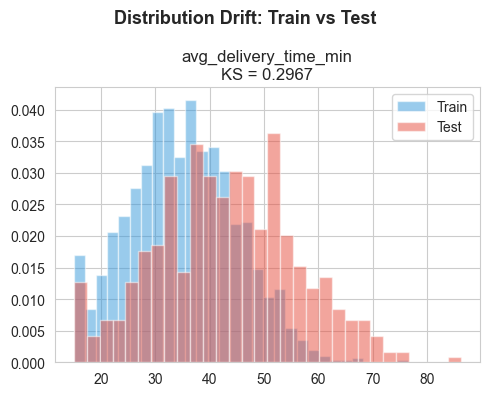

In [8]:
# KS test for numeric columns between train and test
numeric_cols_drift = train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols_drift = [c for c in numeric_cols_drift if c not in ["customer_id", "churned"]]

ks_results = []
for col in numeric_cols_drift:
    train_vals = train[col].dropna()
    test_vals = test[col].dropna()
    stat, pval = stats.ks_2samp(train_vals, test_vals)
    ks_results.append({
        "Feature": col,
        "KS Statistic": round(stat, 4),
        "p-value": f"{pval:.2e}" if pval < 0.001 else f"{pval:.4f}",
        "p_raw": pval,
        "Drift Detected": "YES" if pval < 0.05 else "no"
    })

ks_df = pd.DataFrame(ks_results).sort_values("KS Statistic", ascending=False).reset_index(drop=True)

print("Kolmogorov-Smirnov Test: Train vs Test Distribution")
print("=" * 70)
print(ks_df[["Feature", "KS Statistic", "p-value", "Drift Detected"]].to_string(index=False))

# Identify drifted features
drifted = ks_df[ks_df["Drift Detected"] == "YES"]
if len(drifted) > 0:
    print(f"\n-> {len(drifted)} feature(s) show significant distribution drift (p < 0.05):")
    for _, row in drifted.iterrows():
        print(f"   {row['Feature']}: KS = {row['KS Statistic']}, p = {row['p-value']}")

# Side-by-side distribution plots for drifted features
drifted_features = drifted["Feature"].tolist()
if len(drifted_features) > 0:
    n_plots = min(len(drifted_features), 6)
    fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 4))
    if n_plots == 1:
        axes = [axes]
    for i, feat in enumerate(drifted_features[:n_plots]):
        ax = axes[i]
        ax.hist(train[feat].dropna(), bins=30, alpha=0.5, label="Train", color="#3498db", density=True)
        ax.hist(test[feat].dropna(), bins=30, alpha=0.5, label="Test", color="#e74c3c", density=True)
        ks_val = drifted[drifted["Feature"] == feat]["KS Statistic"].values[0]
        ax.set_title(f"{feat}\nKS = {ks_val}")
        ax.legend()
    plt.suptitle("Distribution Drift: Train vs Test", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("\nNo significant drift detected.")

## 7. Recommendations

### Prioritized Action Items

| Priority | Issue | Action |
|----------|-------|--------|
| 🔴 CRITICAL | **Data Leakage** | Remove `cancellation_rate` — correlation r > 0.95 with target `churned`. This feature almost certainly encodes the outcome and will cause inflated model performance that won't generalize. |
| 🔴 CRITICAL | **Class Imbalance** | ~88/12 split in train. Consider SMOTE, ADASYN, or `class_weight='balanced'` in your classifier. Evaluate with precision-recall AUC, not just accuracy. |
| 🔴 CRITICAL | **Train/Test Drift** | `avg_delivery_time_min` shows significant distribution shift between train and test. Investigate whether this reflects a real temporal change or a data pipeline issue. |
| 🟡 WARNING | **Duplicate Rows** | Remove ~15–20 duplicate rows from the training set to avoid data leakage during cross-validation. |
| 🟡 WARNING | **Mixed Dtypes** | Standardize `has_saved_payment` to boolean. Currently contains both `True`/`False` and `"Yes"`/`"No"` string values. |
| 🟡 WARNING | **Trailing Whitespace** | Strip whitespace from `city` column to prevent spurious category splits. |
| 🔵 INFO | **Near-Constant Column** | Consider dropping `platform` (98% iOS). Low variance features add noise without predictive value. |
| 🔵 INFO | **Missing Values** | Impute `satisfaction_score` (~15% missing) — consider median or model-based imputation. Also address `avg_order_value` (~8% missing). |